# Faster Hybrid Karatsuba: Improvement over the Standard Version

## Aim
Compare four methods:

1. brute force;
2. standard decimal Karatsuba;
3. faster hybrid binary Karatsuba;
4. Python built-in multiplication.

## Mathematics
Binary Karatsuba uses

$$x=a2^m+b, \qquad y=c2^m+d,$$

and the same three-product identity:

$$xy=p2^{2m}+(r-p-q)2^m+q,$$

where

$$p=ac, \qquad q=bd, \qquad r=(a+b)(c+d).$$

The hybrid version uses bit shifts for division and multiplication by powers of two. For small subproblems it uses built-in multiplication. This removes much of the recursive overhead while retaining Karatsuba's structure for larger inputs.


## Before running the code

The code first defines the standard and improved versions. It then gives both versions the same operands. The graphs show:

- all four timing curves;
- the improvement factor `standard Karatsuba time / hybrid Karatsuba time`.


In [9]:
import random, time, statistics, sys
import matplotlib.pyplot as plt
if hasattr(sys,'set_int_max_str_digits'): sys.set_int_max_str_digits(20000)
SEED=20260907; BIT_SIZES=[64,128,256,512,1024,2048,4096]; REPEATS=3; BIT_CUTOFF=256
rng=random.Random(SEED)

def brute_force(x, y):

    # Base case: multiply single-digit integers directly
    if x < 10 or y < 10:
        return x * y

    # Find the maximum number of digits
    n = max(len(str(x)), len(str(y)))

    # Divide the integers approximately into equal halves
    m = n // 2

    # 10^m is used to split the integers
    power = 10 ** m

    # x = a(10^m) + b
    a, b = divmod(x, power)

    # y = c(10^m) + d
    c, d = divmod(y, power)

    # Compute the four smaller products
    ac = brute_force(a, c)
    ad = brute_force(a, d)
    bc = brute_force(b, c)
    bd = brute_force(b, d)

    # Reconstruct the final product
    product = (
        ac * 10 ** (2 * m)
        + (ad + bc) * 10 ** m
        + bd
    )

    return product

def standard_karatsuba(x,y,cutoff_digits=32):
    n=max(len(str(x)),len(str(y)))
    if n<=cutoff_digits: return x*y
    m=n//2; power=10**m; a,b=divmod(x,power); c,d=divmod(y,power)
    p=standard_karatsuba(a,c,cutoff_digits); q=standard_karatsuba(b,d,cutoff_digits); r=standard_karatsuba(a+b,c+d,cutoff_digits)
    return p*10**(2*m)+(r-p-q)*power+q

def hybrid_karatsuba(x,y,cutoff_bits=BIT_CUTOFF):
    if x==0 or y==0: return 0
    n=max(x.bit_length(),y.bit_length())
    if n<=cutoff_bits: return x*y
    m=n//2; mask=(1<<m)-1
    a,b=x>>m,x&mask; c,d=y>>m,y&mask
    p=hybrid_karatsuba(a,c,cutoff_bits); q=hybrid_karatsuba(b,d,cutoff_bits); r=hybrid_karatsuba(a+b,c+d,cutoff_bits)
    return (p<<(2*m))+((r-p-q)<<m)+q

def mean_time(f,x,y):
    times=[]; z=None
    for _ in range(REPEATS): start=time.perf_counter(); z=f(x,y); times.append(time.perf_counter()-start)
    return statistics.mean(times),z


In [10]:
rows=[]
for bits in BIT_SIZES:
    x=rng.getrandbits(bits)|(1<<(bits-1)); y=rng.getrandbits(bits)|(1<<(bits-1))
    tb,z1=mean_time(brute_force,x,y); ts,z2=mean_time(standard_karatsuba,x,y); th,z3=mean_time(hybrid_karatsuba,x,y); tp,z4=mean_time(lambda u,v:u*v,x,y)
    assert z1==z2==z3==z4
    rows.append((bits,tb,ts,th,tp)); print(f'{bits:4d} bits: brute={tb:.3e}, standard={ts:.3e}, hybrid={th:.3e}, built-in={tp:.3e}, improvement={ts/th:.2f}x')


  64 bits: brute=1.864e-04, standard=1.367e-06, hybrid=1.000e-06, built-in=3.000e-07, improvement=1.37x
 128 bits: brute=4.889e-04, standard=5.167e-06, hybrid=8.333e-07, built-in=3.000e-07, improvement=6.20x
 256 bits: brute=2.212e-03, standard=1.683e-05, hybrid=8.667e-07, built-in=4.000e-07, improvement=19.42x
 512 bits: brute=9.626e-03, standard=4.390e-05, hybrid=4.900e-06, built-in=6.000e-07, improvement=8.96x
1024 bits: brute=3.484e-02, standard=9.963e-05, hybrid=1.080e-05, built-in=9.000e-07, improvement=9.23x
2048 bits: brute=1.241e-01, standard=3.839e-04, hybrid=3.903e-05, built-in=4.000e-06, improvement=9.84x
4096 bits: brute=5.005e-01, standard=1.188e-03, hybrid=1.307e-04, built-in=1.213e-05, improvement=9.09x


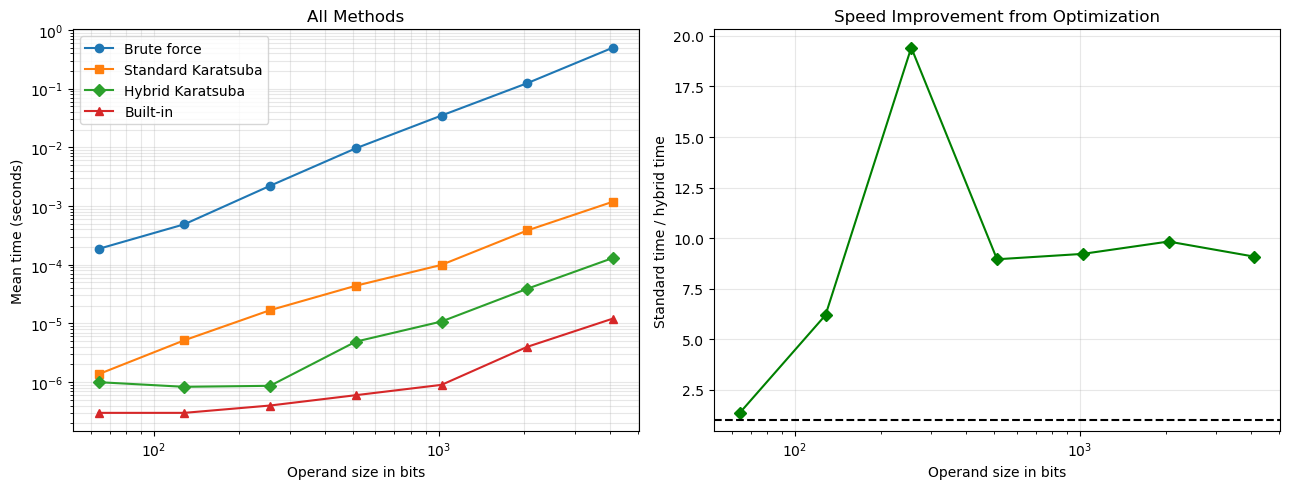

In [11]:
n=[r[0] for r in rows]; tb=[r[1] for r in rows]; ts=[r[2] for r in rows]; th=[r[3] for r in rows]; tp=[r[4] for r in rows]
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].loglog(n,tb,'o-',label='Brute force'); ax[0].loglog(n,ts,'s-',label='Standard Karatsuba'); ax[0].loglog(n,th,'D-',label='Hybrid Karatsuba'); ax[0].loglog(n,tp,'^-',label='Built-in')
ax[0].set(xlabel='Operand size in bits',ylabel='Mean time (seconds)',title='All Methods'); ax[0].grid(True,which='both',alpha=.3); ax[0].legend()
improvement=[s/h for s,h in zip(ts,th)]
ax[1].semilogx(n,improvement,'D-',color='green'); ax[1].axhline(1,color='black',ls='--')
ax[1].set(xlabel='Operand size in bits',ylabel='Standard time / hybrid time',title='Speed Improvement from Optimization'); ax[1].grid(True,alpha=.3)
plt.tight_layout(); plt.show()


### Meaning of the graphs

- The left graph directly compares brute force, standard Karatsuba, improved hybrid Karatsuba and the built-in method.
- In the right graph, a value of $8$ means that hybrid Karatsuba is 8 times faster than standard Karatsuba.
- A value above $1$ confirms an improvement; a value below $1$ means the optimization did not help at that size.
- The hybrid version improves speed by replacing decimal splitting with bit operations and stopping recursion at a suitable cutoff.


## Exercise

### Measure improvement
For bit sizes 256, 512, 1024 and 2048, compute $t_S/t_H$, where $t_S$ is standard Karatsuba time and $t_H$ is hybrid Karatsuba time. Plot the ratio and identify the largest improvement.


 256 bits: brute=3.291e-03, standard=1.490e-05, hybrid=1.200e-06, built-in=4.000e-07, improvement=12.42x
 512 bits: brute=8.594e-03, standard=4.400e-05, hybrid=5.700e-06, built-in=7.333e-07, improvement=7.72x
1024 bits: brute=2.973e-02, standard=1.159e-04, hybrid=1.327e-05, built-in=1.267e-06, improvement=8.74x
2048 bits: brute=1.082e-01, standard=3.825e-04, hybrid=4.070e-05, built-in=4.233e-06, improvement=9.40x


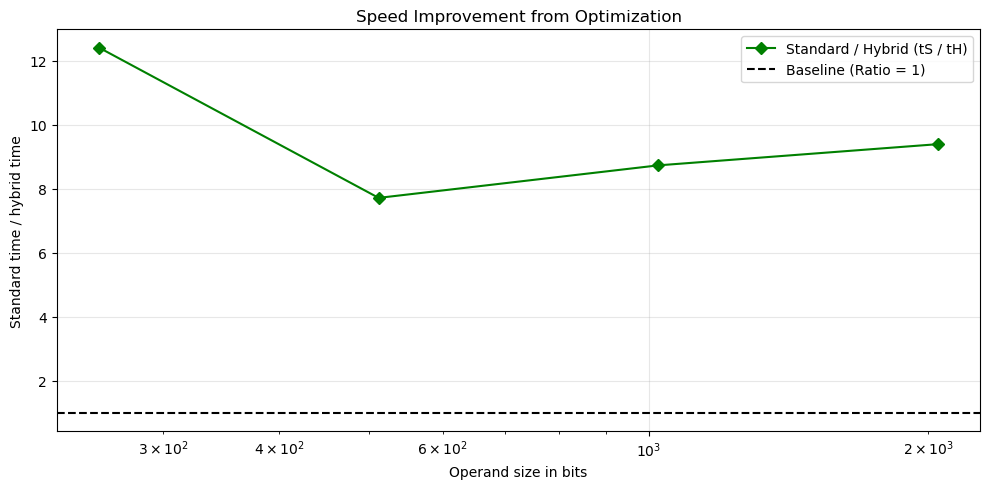

In [13]:
BIT_SIZES = [256,512,1024,2048]
REPEATS=3

rows=[]
for bits in BIT_SIZES:
    x=rng.getrandbits(bits)|(1<<(bits-1)); y=rng.getrandbits(bits)|(1<<(bits-1))
    tb,z1=mean_time(brute_force,x,y); ts,z2=mean_time(standard_karatsuba,x,y); th,z3=mean_time(hybrid_karatsuba,x,y); tp,z4=mean_time(lambda u,v:u*v,x,y)
    assert z1==z2==z3==z4
    rows.append((bits,tb,ts,th,tp)); print(f'{bits:4d} bits: brute={tb:.3e}, standard={ts:.3e}, hybrid={th:.3e}, built-in={tp:.3e}, improvement={ts/th:.2f}x')

n=[r[0] for r in rows]; tb=[r[1] for r in rows]; ts=[r[2] for r in rows]; th=[r[3] for r in rows]
improvement = [s / h for s, h in zip(ts, th)]

plt.figure(figsize=(10, 5))
plt.semilogx(n, improvement, 'D-', color='green', label='Standard / Hybrid (tS / tH)')
plt.axhline(1, color='black', ls='--', label='Baseline (Ratio = 1)')

# Fixed plt.xlabel
plt.xlabel('Operand size in bits')
plt.ylabel('Standard time / hybrid time')
plt.title('Speed Improvement from Optimization')
plt.grid(True, alpha=.3)
plt.legend()

plt.tight_layout()
plt.show()

Significant performace improvement observed at bit size 5*10^2 